# Energy Overlay (2–3 MeV)

This notebook is organized by component.  
Each component has its own editable cell where you can set:

- the minimum `y` value used on the main spectrum plot
- the total simulated decays/events used for normalization
- the radii/configurations and reference curve for the ratio panel

The ratio panel is computed with a safer masking rule, and the `0νββ` region appears only once in the legend.


In [1]:

%matplotlib inline
from pathlib import Path
import sys
import re
from typing import Iterable, List, Optional, Dict, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import uproot

# Resolve repo root even when __file__ is undefined (e.g. notebook execution)
REPO_ROOT = Path.cwd()
for p in [REPO_ROOT] + list(REPO_ROOT.parents):
    if p.name == "nexo-py-recon":
        REPO_ROOT = p
        break
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from nexo_py_recon.contexts import global_context

# Standalone HFE label conversion so this notebook runs without local helper modules.
HFE_DENSITY_T_PER_M3 = 1.73
HFE_DEFAULT_RIC_M = 1.691
HFE_TPC_RADIUS_M = 0.6385
HFE_TPC_HEIGHT_M = 1.277
HFE_BASELINE_TARGET_MASS_KG = 31810.0

def hfe_volume_m3(ric_m: float) -> float:
    sphere_volume_m3 = (4.0 / 3.0) * np.pi * ric_m**3
    tpc_cylinder_volume_m3 = np.pi * HFE_TPC_RADIUS_M**2 * HFE_TPC_HEIGHT_M
    return float(sphere_volume_m3 - tpc_cylinder_volume_m3)

def hfe_mass_tonnes_from_iv_radius_mm(iv_radius_mm: int) -> float:
    baseline_ideal_t = HFE_DENSITY_T_PER_M3 * hfe_volume_m3(HFE_DEFAULT_RIC_M)
    calibration_loss_t = baseline_ideal_t - HFE_BASELINE_TARGET_MASS_KG / 1000.0
    return float(HFE_DENSITY_T_PER_M3 * hfe_volume_m3(iv_radius_mm / 1000.0) - calibration_loss_t)

HFE_LABEL_OVERRIDES = {
    1000: "4.0 t HFE",
    1026: "4.5 t HFE",
    1100: "6.5 t HFE",
    1226: "10 t HFE",
    1300: "13 t HFE",
    1510: "22 t HFE",
    1691: "32 t HFE",
}

sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)


Welcome to JupyROOT 6.26/06


In [2]:
def discover_runs(data_dir: Path) -> List[str]:
    runs = sorted({p.name.split("-")[0] for p in data_dir.glob("*-Energy-*")})
    return [r for r in runs if "{" not in r and "}" not in r]


def histogram_energy(ctx, run_ids: Iterable[str], lo: float, hi: float, bins: int = 150):
    hist = np.zeros(bins, dtype=np.int64)
    edges = None
    for rid in run_ids:
        df = ctx.get_df(run_id=rid, targets=["Energy"], progress_bar=False)
        arr = df["energy"].to_numpy()
        h, edges = np.histogram(arr, bins=bins, range=(lo, hi))
        hist += h
    return hist, edges


def smooth(arr: np.ndarray, window: int) -> np.ndarray:
    if window <= 1:
        return arr
    kernel = np.ones(window, dtype=float) / float(window)
    return np.convolve(arr, kernel, mode="same")


def parse_total_decays(jobs_dir: Path) -> Optional[float]:
    script = jobs_dir / "job_script.sh"
    if not script.is_file():
        return None
    text = script.read_text()
    m_evt = re.search(r"--evtmax\s+(\d+)", text)
    m_arr = re.search(r"--array=([0-9]+)-([0-9]+)", text)
    if not m_evt:
        return None
    evtmax = int(m_evt.group(1))
    if m_arr:
        start, end = int(m_arr.group(1)), int(m_arr.group(2))
        njobs = end - start + 1
    else:
        njobs = 1
    return float(evtmax * njobs)


def resolve_radius_dir(reco_root: Path, radius_name: str) -> Optional[Path]:
    candidates = [
        Path(radius_name),
        Path(f"{radius_name}mmIV"),
    ]
    for candidate in candidates:
        if (reco_root / candidate).is_dir():
            return candidate
    return None


def get_normalization_total(
    normalization_totals: Optional[Union[Dict[str, float], float, int]],
    label: str,
    jobs_dir: Path,
) -> Optional[float]:
    if normalization_totals is None:
        return parse_total_decays(jobs_dir)

    if isinstance(normalization_totals, (int, float)):
        return float(normalization_totals)

    if isinstance(normalization_totals, dict):
        if label in normalization_totals:
            return float(normalization_totals[label])
        return parse_total_decays(jobs_dir)

    raise TypeError(
        f"normalization_totals must be None, a number, or a dict; got {type(normalization_totals)}"
    )


def deduplicate_legend(ax, extra_handles=None, extra_labels=None, **legend_kwargs):
    handles, labels = ax.get_legend_handles_labels()
    pairs = []
    seen = set()
    for h, l in zip(handles, labels):
        if not l or l == "_nolegend_" or l in seen:
            continue
        pairs.append((h, l))
        seen.add(l)

    if extra_handles and extra_labels:
        for h, l in zip(extra_handles, extra_labels):
            if not l or l == "_nolegend_" or l in seen:
                continue
            pairs.append((h, l))
            seen.add(l)

    if pairs:
        leg_handles, leg_labels = zip(*pairs)
        ax.legend(leg_handles, leg_labels, **legend_kwargs)


def format_radius_label(label: str) -> str:
    parts = [p for p in label.split("_") if p and p.upper() not in {"HFE"}]
    parts = parts or [label]
    formatted = []
    pattern = re.compile(r"^(\d+)(mm)?([A-Za-z]+)?$")

    for part in parts:
        m = pattern.match(part)
        if m:
            number, mm_tag, suffix = m.groups()
            text = number
            text += " mm"
            if suffix:
                text += f" {suffix.upper()}"
            formatted.append(text)
        else:
            formatted.append(part.replace("_", " "))

    return " / ".join(formatted)


def extract_iv_radius_mm(label: str) -> Optional[int]:
    parts = [p for p in label.split("_") if p]
    iv_pattern = re.compile(r"^(\d+)(?:mm)?IV$", re.IGNORECASE)
    numeric_pattern = re.compile(r"^(\d+)(?:mm)?$", re.IGNORECASE)

    for part in parts:
        m = iv_pattern.match(part)
        if m:
            return int(m.group(1))

    if parts:
        m = numeric_pattern.match(parts[0])
        if m:
            return int(m.group(1))

    return None


def format_hfe_quantity_label(label: str) -> str:
    iv_radius_mm = extract_iv_radius_mm(label)
    if iv_radius_mm is None:
        return format_radius_label(label)

    hfe_label = HFE_LABEL_OVERRIDES.get(iv_radius_mm)
    if hfe_label is None:
        hfe_mass_t = hfe_mass_tonnes_from_iv_radius_mm(iv_radius_mm)
        hfe_label = f"{hfe_mass_t:.2f} t HFE"
    parts = [p for p in label.split("_") if p]
    formatted = []
    radius_pattern = re.compile(r"^(\d+)(mm)?([A-Za-z]+)?$")
    iv_pattern = re.compile(r"^(\d+)(?:mm)?IV$", re.IGNORECASE)
    numeric_pattern = re.compile(r"^(\d+)(?:mm)?$", re.IGNORECASE)
    hfe_label_added = False

    for idx, part in enumerate(parts):
        if iv_pattern.match(part):
            if not hfe_label_added:
                formatted.append(hfe_label)
                hfe_label_added = True
            continue

        if not hfe_label_added and idx == 0 and numeric_pattern.match(part):
            formatted.append(hfe_label)
            hfe_label_added = True
            continue

        if part.upper() == "HFE":
            continue

        m = radius_pattern.match(part)
        if m:
            number, mm_tag, suffix = m.groups()
            text = f"{number} mm"
            if suffix:
                text += f" {suffix.upper()}"
            formatted.append(text)
        else:
            formatted.append(part.replace("_", " "))

    if not formatted:
        return hfe_label

    return " / ".join(formatted)


def format_isotope_label(isotope: str) -> str:
    m = re.match(r"([A-Za-z]+)(\d+)$", isotope)
    if m:
        element, mass = m.groups()
        return rf"$^{{{mass}}}$" + element
    return isotope


def plot_overlay(
    isotope: str,
    reco_root: Path,
    input_root: Path,
    radii: List[str],
    reference_radius: Optional[str] = None,
    normalization_totals: Optional[Dict[str, float]] = None,
    bins: int = 150,
    emin: float = 2000.0,
    emax: float = 3000.0,
    smooth_bins: int = 5,
    ratio_floor: float = 1e-20,
    ratio_ylim: Optional[Tuple[float, float]] = None,
    ratio_min_span: float = 0.08,
    ratio_pad_fraction: float = 0.20,
    ymin: Optional[float] = None,
    logy: bool = True,
    normalize_decays: bool = True,
    title_prefix: Optional[str] = None,
):
    fig, (ax, rax) = plt.subplots(
        2,
        1,
        figsize=(12, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        constrained_layout=True,
    )

    bin_width = (emax - emin) / bins
    spectra = {}
    reference_label = None
    color_map = {}

    for r in radii:
        radius_dir = resolve_radius_dir(reco_root, r)
        if radius_dir is None:
            print(f"Skip {r}: missing radius directory under {reco_root}")
            continue

        raw_label = radius_dir.name
        label = format_hfe_quantity_label(raw_label)
        data_dir = reco_root / radius_dir / isotope / "strax_data"
        input_base = input_root / radius_dir / isotope / "data"
        jobs_dir = input_root / radius_dir / isotope / "jobs"

        if not data_dir.is_dir():
            print(f"Skip {label}: missing {data_dir}")
            continue

        run_ids = discover_runs(data_dir)
        if not run_ids:
            print(f"Skip {label}: no Energy data found")
            continue

        ctx = global_context(data_dir=str(data_dir), input_basepath=str(input_base))
        hist, edges = histogram_energy(ctx, run_ids, emin, emax, bins)
        centers = 0.5 * (edges[:-1] + edges[1:])

        spectrum = hist.astype(float) / bin_width
        total_norm = None
        if normalize_decays:
            total_norm = get_normalization_total(normalization_totals, raw_label, jobs_dir)
            if total_norm and total_norm > 0:
                spectrum = spectrum / total_norm
            else:
                print(f"Warning: could not determine normalization total for {label}; leaving raw counts.")

        spectrum = smooth(spectrum, smooth_bins)
        spectra[label] = {
            "centers": centers,
            "spectrum": spectrum,
            "total_norm": total_norm,
            "run_count": len(run_ids),
        }
        line, = ax.step(centers, spectrum, where="mid", lw=1.8, label=label)
        color_map[label] = line.get_color()

        if reference_radius is not None:
            if raw_label == reference_radius or r == reference_radius or label == reference_radius:
                reference_label = label

    if not spectra:
        raise RuntimeError("No spectra plotted; check paths and radii")

    if reference_label is None:
        reference_label = next(iter(spectra.keys()))
        if reference_radius is not None:
            print(f"Reference '{reference_radius}' not found exactly. Using '{reference_label}' instead.")

    ref_spec = spectra[reference_label]["spectrum"]

    # ---------------- Ratio panel ----------------
    rax.axhline(1.0, lw=1.0, linestyle="--", color="0.4", label="_nolegend_")
    all_ratio_values = []

    for label, payload in spectra.items():
        if label == reference_label:
            continue

        spectrum = payload["spectrum"]
        centers = payload["centers"]

        valid = (
            np.isfinite(spectrum)
            & np.isfinite(ref_spec)
            & (spectrum > ratio_floor)
            & (ref_spec > ratio_floor)
        )

        ratio = np.full_like(spectrum, np.nan, dtype=float)
        ratio[valid] = spectrum[valid] / ref_spec[valid]

        finite_ratio = ratio[np.isfinite(ratio)]
        if finite_ratio.size:
            rax.step(
                centers,
                ratio,
                where="mid",
                lw=1.4,
                label=label,
                color=color_map.get(label),
            )
            all_ratio_values.append(finite_ratio)

    if ratio_ylim is not None:
        rax.set_ylim(*ratio_ylim)
    elif all_ratio_values:
        finite_vals = np.concatenate(all_ratio_values)
        finite_vals = finite_vals[np.isfinite(finite_vals)]

        if finite_vals.size:
            q_low, q_high = np.nanpercentile(finite_vals, [2, 98])

            half_span = max(
                abs(q_low - 1.0),
                abs(q_high - 1.0),
                ratio_min_span,
            )
            half_span *= (1.0 + ratio_pad_fraction)

            y_low = max(0.0, 1.0 - half_span)
            y_high = 1.0 + half_span

            if y_high - y_low < 2 * ratio_min_span:
                y_low = max(0.0, 1.0 - ratio_min_span)
                y_high = 1.0 + ratio_min_span

            rax.set_ylim(y_low, y_high)
        else:
            rax.set_ylim(0.8, 1.2)
    else:
        rax.set_ylim(0.8, 1.2)

    rax.set_ylabel("Ratio")
    # Intentionally no legend in ratio panel to avoid duplication

    # ---------------- Main axis ----------------
    ylabel = "Events / keV"
    if normalize_decays:
        ylabel = "Events / keV / simulated decay"
    ax.set_ylabel(ylabel)

    iso_label = format_isotope_label(isotope)
    title = f"{iso_label} Energy Spectra"
    ax.set_title(title)
    ax.set_yscale("log" if logy else "linear")
    ax.set_xlim(emin, emax)
    rax.set_xlim(emin, emax)

    gamma_lines = {"Th232": [2615], "U238": [2447]}
    QBB = 2458.0
    gamma_lines = {k: list(v) for k, v in gamma_lines.items()}
    isotope_lines = gamma_lines.get(isotope, []).copy()
    if QBB not in isotope_lines:
        isotope_lines.append(QBB)
    sigma_qbb = 0.008 * QBB

    positive_vals = [
        payload["spectrum"][payload["spectrum"] > 0]
        for payload in spectra.values()
        if np.any(payload["spectrum"] > 0)
    ]
    if positive_vals:
        positive = np.concatenate(positive_vals)
        auto_ymin = positive.min() * (0.5 if logy else 0.8)
        auto_ymax = positive.max() * 1.2
        ax.set_ylim(ymin if ymin is not None else auto_ymin, auto_ymax)
    elif ymin is not None:
        ax.set_ylim(bottom=ymin)

    current_ymin, current_ymax = ax.get_ylim()
    y_text = current_ymin * 1.05 if logy else current_ymin + 0.02 * (current_ymax - current_ymin)

    for g in isotope_lines:
        ax.axvline(g, color="0.5", lw=1.0, linestyle="--", label="_nolegend_")

        if float(g).is_integer():
            g_label = f"{int(g)} keV"
        else:
            g_label = f"{g:g} keV"

        if np.isclose(g, 2447.0):
            ax.text(g - 3, y_text, g_label, rotation=90, va="bottom", ha="right")
        else:
            ax.text(g + 3, y_text, g_label, rotation=90, va="bottom", ha="left")

    region_handle = ax.axvspan(
        QBB - 3 * sigma_qbb,
        QBB + 3 * sigma_qbb,
        color="tab:red",
        alpha=0.3,
        label="_nolegend_",
    )

    extra_handles = [region_handle] if region_handle is not None else None
    extra_labels = [r"$0\nu\beta\beta:\ \sigma_E/E=0.8\%$"] if region_handle is not None else None
    deduplicate_legend(
        ax,
        extra_handles=extra_handles,
        extra_labels=extra_labels,
        frameon=True,
        ncol=2,
    )

    rax.set_xlabel("Deposited energy [keV]")
    plt.show()
    return fig, spectra


def plot_component(component_name: str, config: Dict, isotope_configs: Dict[str, Dict]):
    for isotope, opts in isotope_configs.items():
        print(f"Plotting {component_name} {isotope}")
        plot_overlay(
            isotope=isotope,
            reco_root=config["reco_root"],
            input_root=config["input_root"],
            radii=config["radii"],
            reference_radius=config["reference_radius"],
            normalization_totals=opts.get("normalization_totals"),
            bins=opts.get("bins", config.get("bins", 150)),
            emin=opts.get("emin", config.get("emin", 2000.0)),
            emax=opts.get("emax", config.get("emax", 3000.0)),
            smooth_bins=opts.get("smooth_bins", config.get("smooth_bins", 5)),
            ratio_floor=opts.get("ratio_floor", config.get("ratio_floor", 1e-20)),
            ratio_ylim=opts.get("ratio_ylim", config.get("ratio_ylim")),
            ymin=opts.get("ymin"),
            logy=opts.get("logy", config.get("logy", True)),
            normalize_decays=opts.get("normalize_decays", config.get("normalize_decays", True)),
            title_prefix=component_name,
        )


## IV

Edit `ymin` and `normalization_totals` below.
If `normalization_totals` is `None`, the notebook will try to read the total from `jobs/job_script.sh`.


Plotting IV Th232


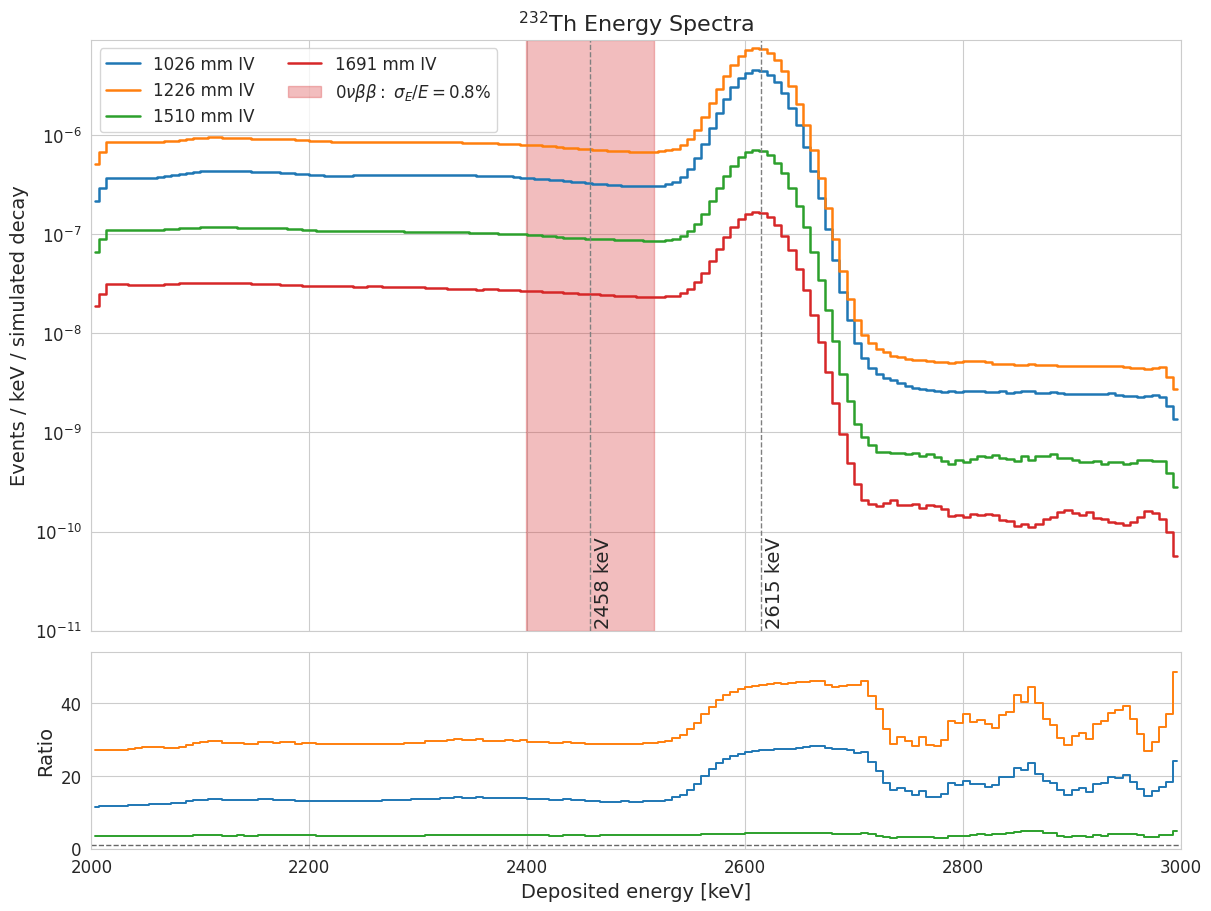

Plotting IV U238


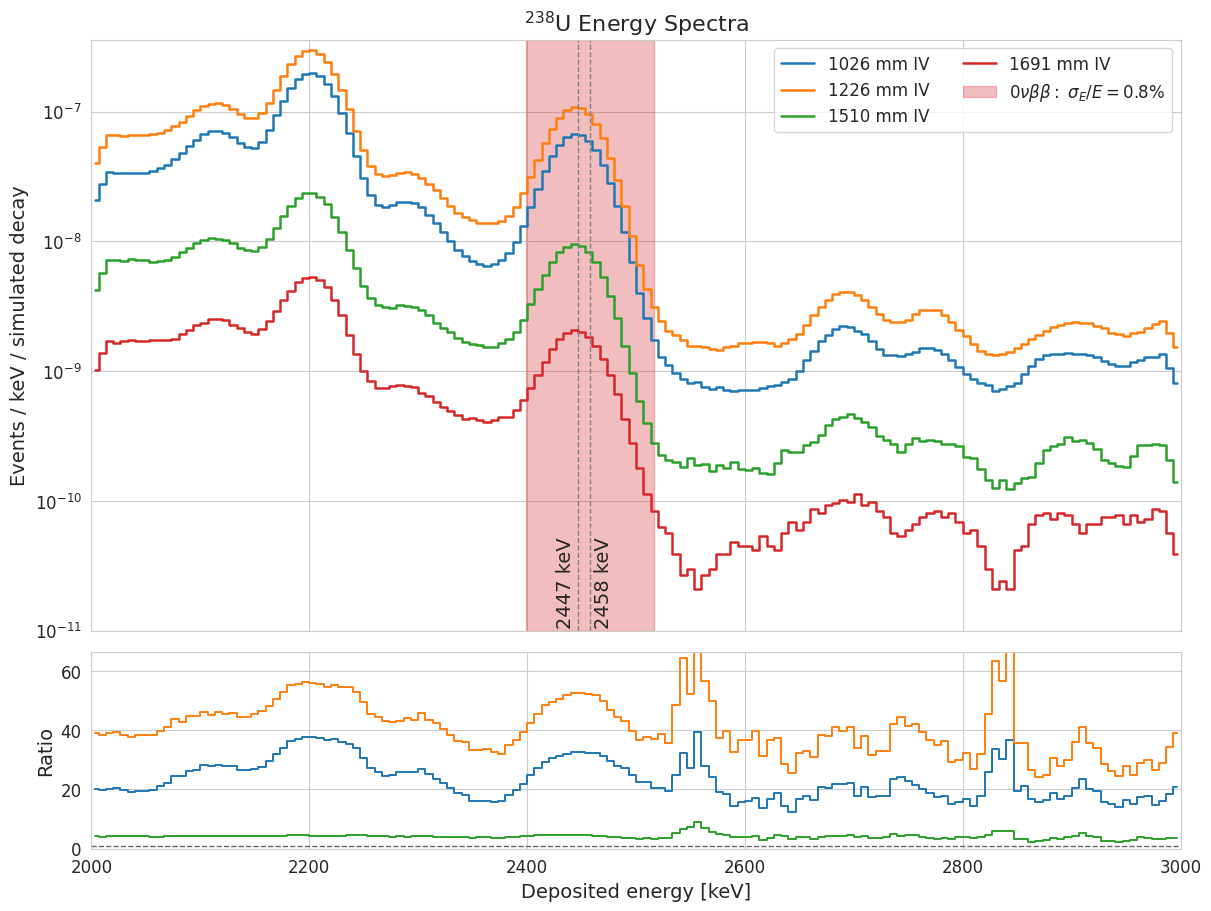

In [3]:
IV_CONFIG = {
    "reco_root": REPO_ROOT / "data/2025_06/IVbkgd_amy0625_10B-recon0625_DNN088",
    "input_root": Path("/p/lustre2/amy1/IVbkgd_amy0625_10B"),
    "radii": ["1026", "1226", "1510", "1691"],
    "reference_radius": "1691",
    "bins": 150,
    "emin": 2000.0,
    "emax": 3000.0,
    "smooth_bins": 5,
    "ratio_floor": 1e-20,
    "logy": True,
    "normalize_decays": True,
}

IV_ISOTOPES = {
    "Th232": {
        "ymin": 1e-11,
        "normalization_totals": 1e10,
    },
    "U238": {
        "ymin": 1e-11,
        "normalization_totals": 1e10,
    },
}

plot_component("IV", IV_CONFIG, IV_ISOTOPES)


## OV

Plotting OV Th232


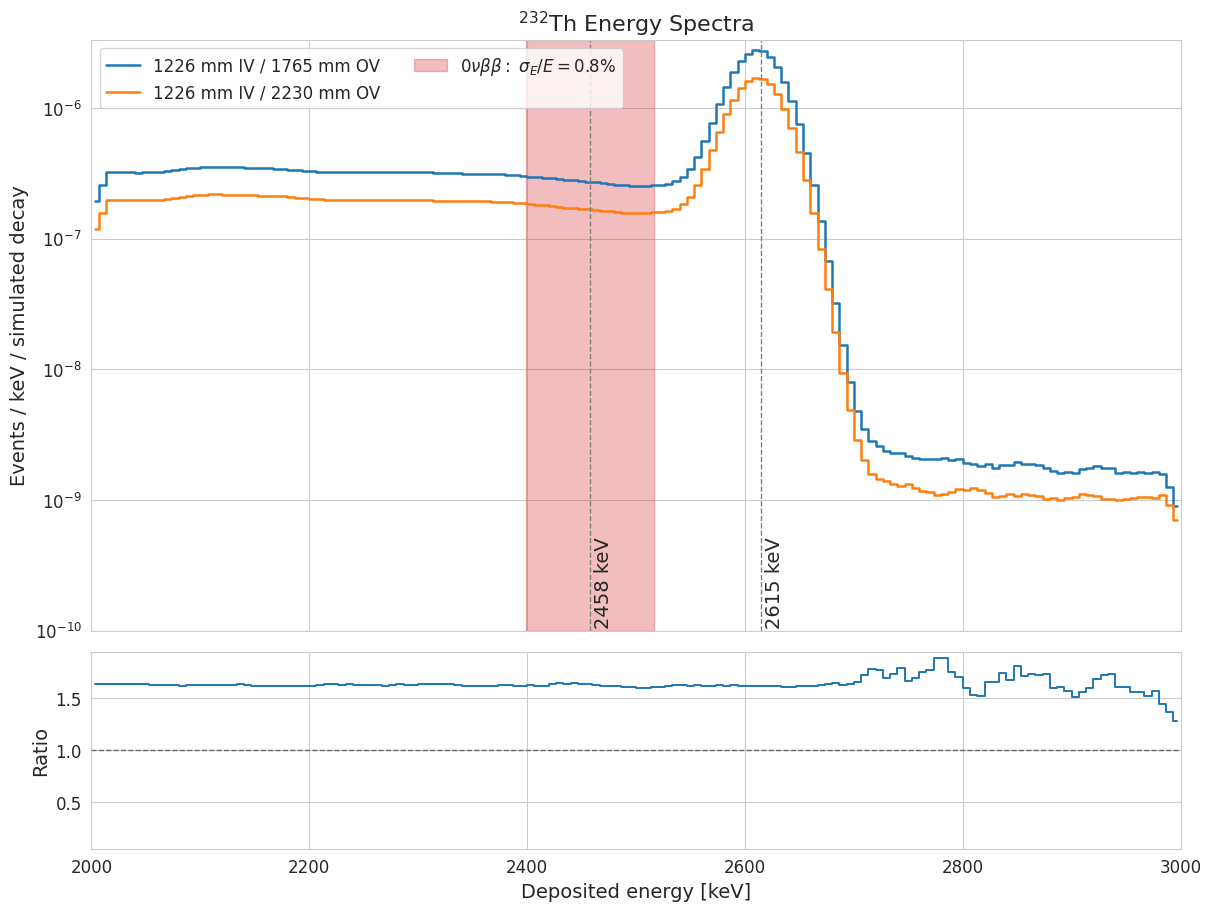

Plotting OV U238


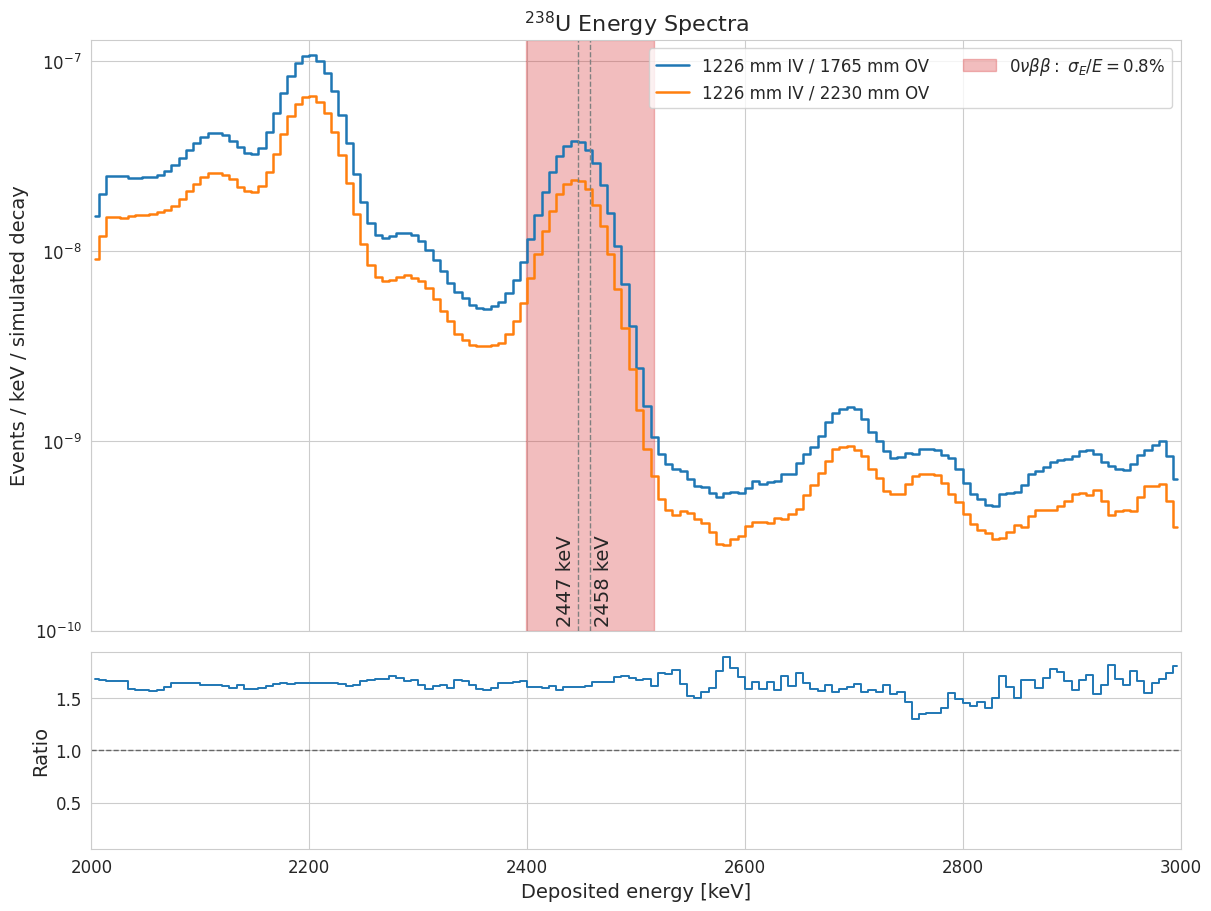

In [4]:
OV_CONFIG = {
    "reco_root": REPO_ROOT / "data/2025_06/OVbkgd_amy0625-recon0625_DNN088",
    "input_root": Path("/p/lustre2/amy1/OVbkgd_amy0625"),
    "radii": ["1226mmIV_1765mmOV", "1226mmIV_2230mmOV"],
    "reference_radius": "1226mmIV_2230mmOV",
    "bins": 150,
    "emin": 2000.0,
    "emax": 3000.0,
    "smooth_bins": 5,
    "ratio_floor": 1e-20,
    "logy": True,
    "normalize_decays": True,
}

OV_ISOTOPES = {
    "Th232": {
        "ymin": 1e-10,
        "normalization_totals": 1e10,
    },
    "U238": {
        "ymin": 1e-10,
        "normalization_totals": 1e10,
    },
}

plot_component("OV", OV_CONFIG, OV_ISOTOPES)


## HFE

Plotting HFE Th232


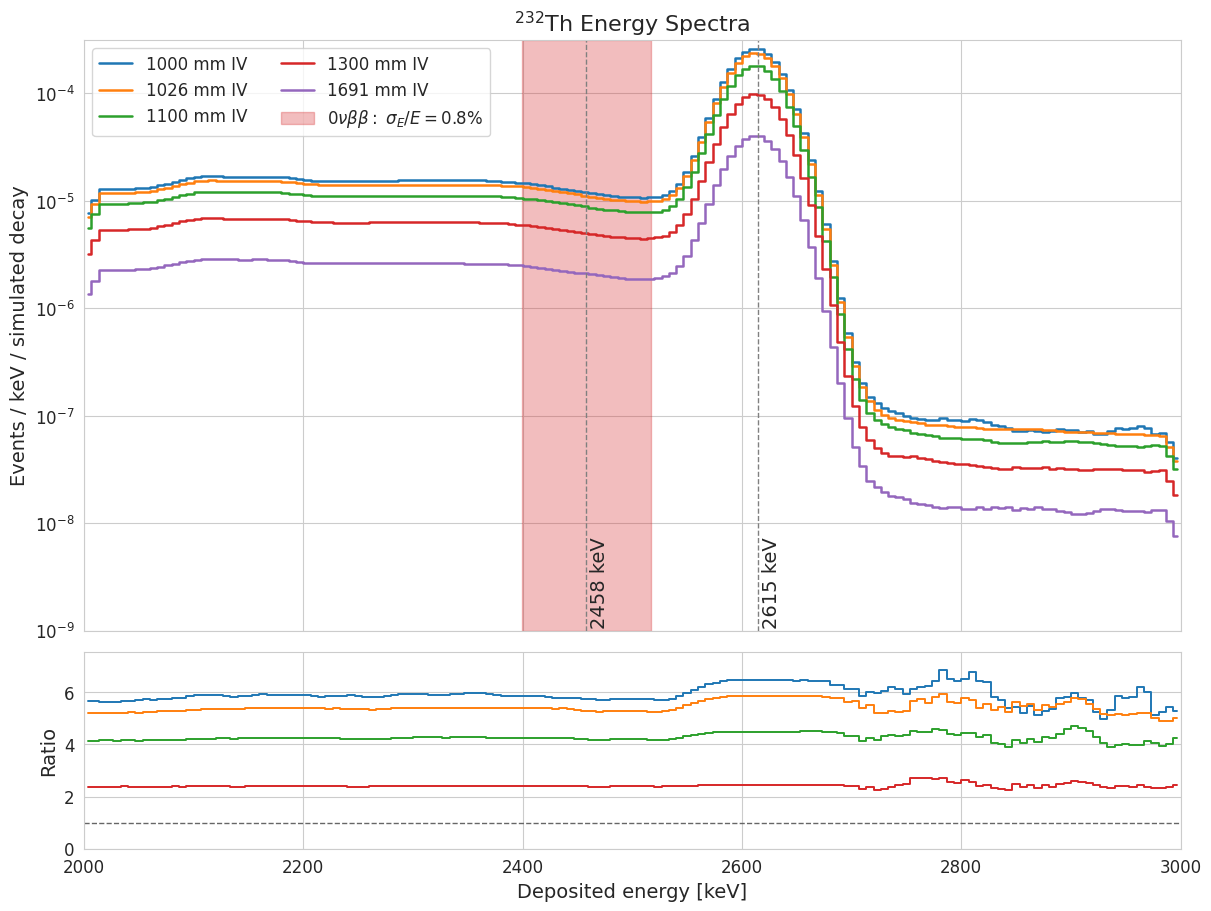

Plotting HFE U238


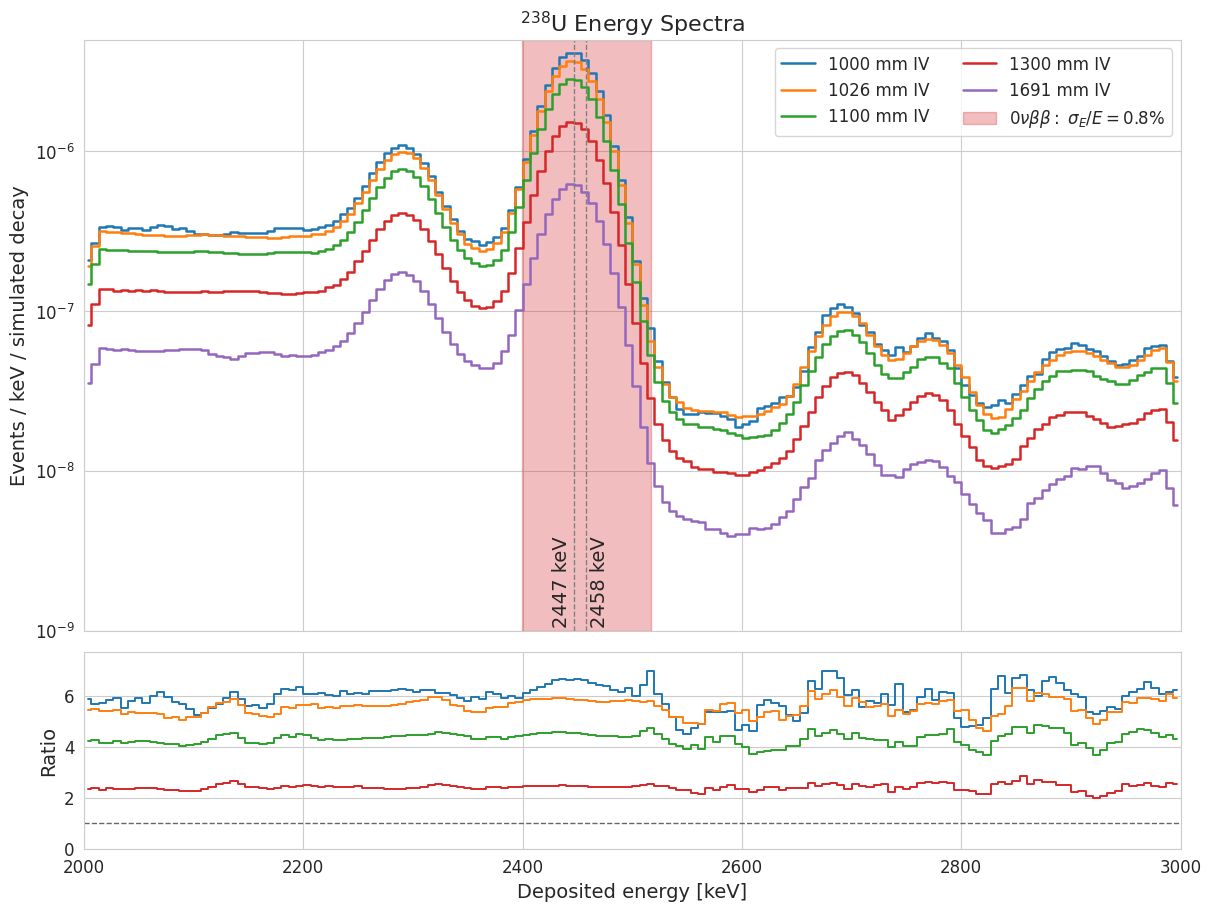

In [5]:
HFE_CONFIG = {
    "reco_root": REPO_ROOT / "data/2025_06/HFEbkgd_amy0625_1B-recon0625_DNN088",
    "input_root": Path("/p/lustre1/amy1/HFEbkgd_amy0625_1B"),
    "radii": ["1000mmIV_HFE", "1026mmIV_HFE", "1100mmIV_HFE", "1300mmIV_HFE", "1691mmIV_HFE"],
    "reference_radius": "1691mmIV_HFE",
    "bins": 150,
    "emin": 2000.0,
    "emax": 3000.0,
    "smooth_bins": 5,
    "ratio_floor": 1e-20,
    "logy": True,
    "normalize_decays": True,
}

HFE_ISOTOPES = {
    "Th232": {
        "ymin": 1e-9,
        "normalization_totals": {
            "1000mmIV_HFE": 1e8,
            "1026mmIV_HFE": 1e9,
            "1100mmIV_HFE": 1e9,
            "1300mmIV_HFE": 1e9,
            "1691mmIV_HFE": 1e9,
        },
    },
    "U238": {
        "ymin": 1e-9,
        "normalization_totals": {
            "1000mmIV_HFE": 1e8,
            "1026mmIV_HFE": 1e9,
            "1100mmIV_HFE": 1e9,
            "1300mmIV_HFE": 1e9,
            "1691mmIV_HFE": 1e9,
        },
    },
}

plot_component("HFE", HFE_CONFIG, HFE_ISOTOPES)

## Water

Plotting Water Th232


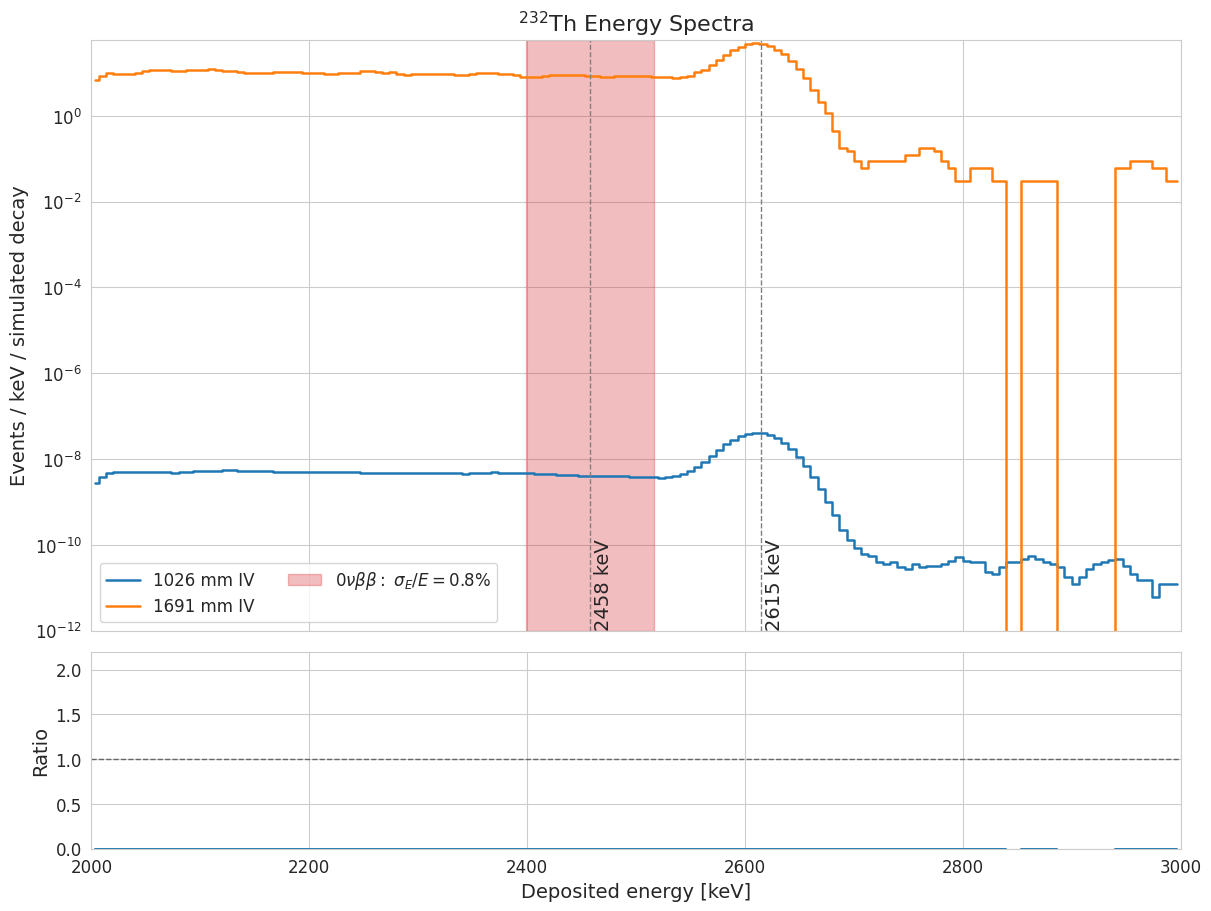

Plotting Water U238


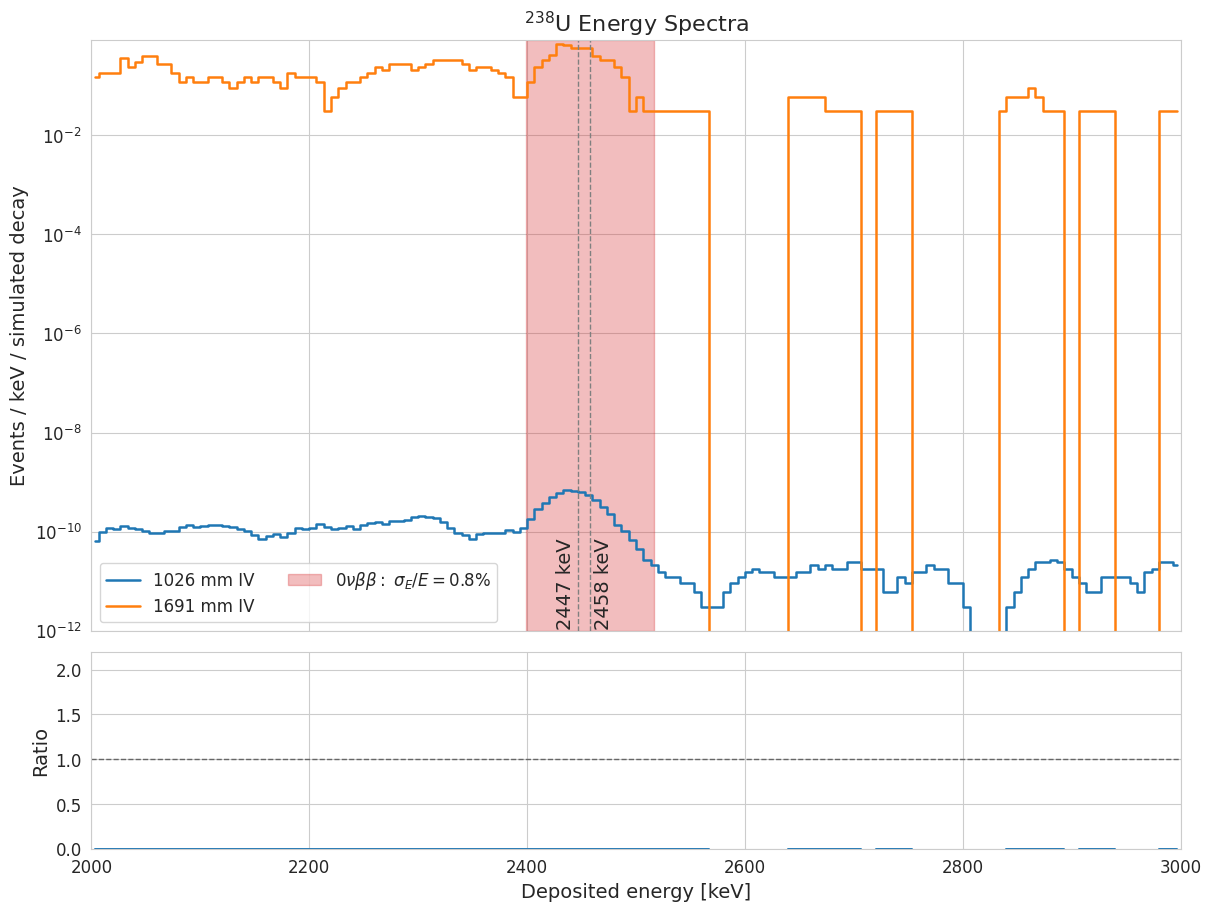

In [6]:
WATER_CONFIG = {
    "reco_root": REPO_ROOT / "data/2025_06/Waterbkgd_amy0625-recon0625_DNN088",
    "input_root": Path("/p/lustre2/amy1/Waterbkgd_amy0625"),
    "radii": ["1026", "1691"],
    "reference_radius": "1691",
    "bins": 150,
    "emin": 2000.0,
    "emax": 3000.0,
    "smooth_bins": 5,
    "ratio_floor": 1e-20,
    "logy": True,
    "normalize_decays": True,
}

WATER_ISOTOPES = {
    "Th232": {
        "ymin": 1e-12,
        "normalization_totals": {
            "1026": 1e10,
            "1691": 1e11,
        },
    },
    "U238": {
        "ymin": 1e-12,
        "normalization_totals": {
            "1026": 1e10,
            "1691": 1e11,
        },
    },
}

plot_component("Water", WATER_CONFIG, WATER_ISOTOPES)

## Transition box

Plotting Transition box Th232


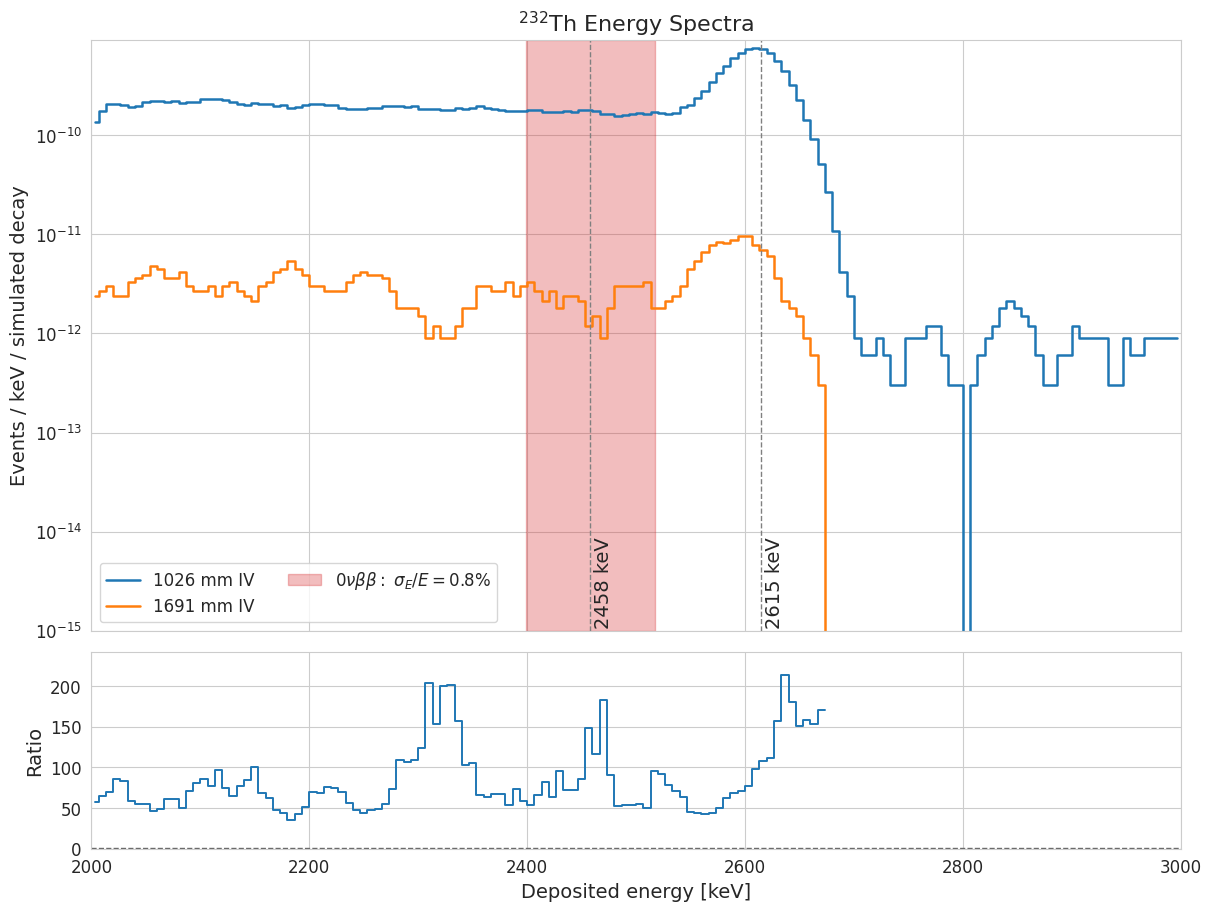

Plotting Transition box U238


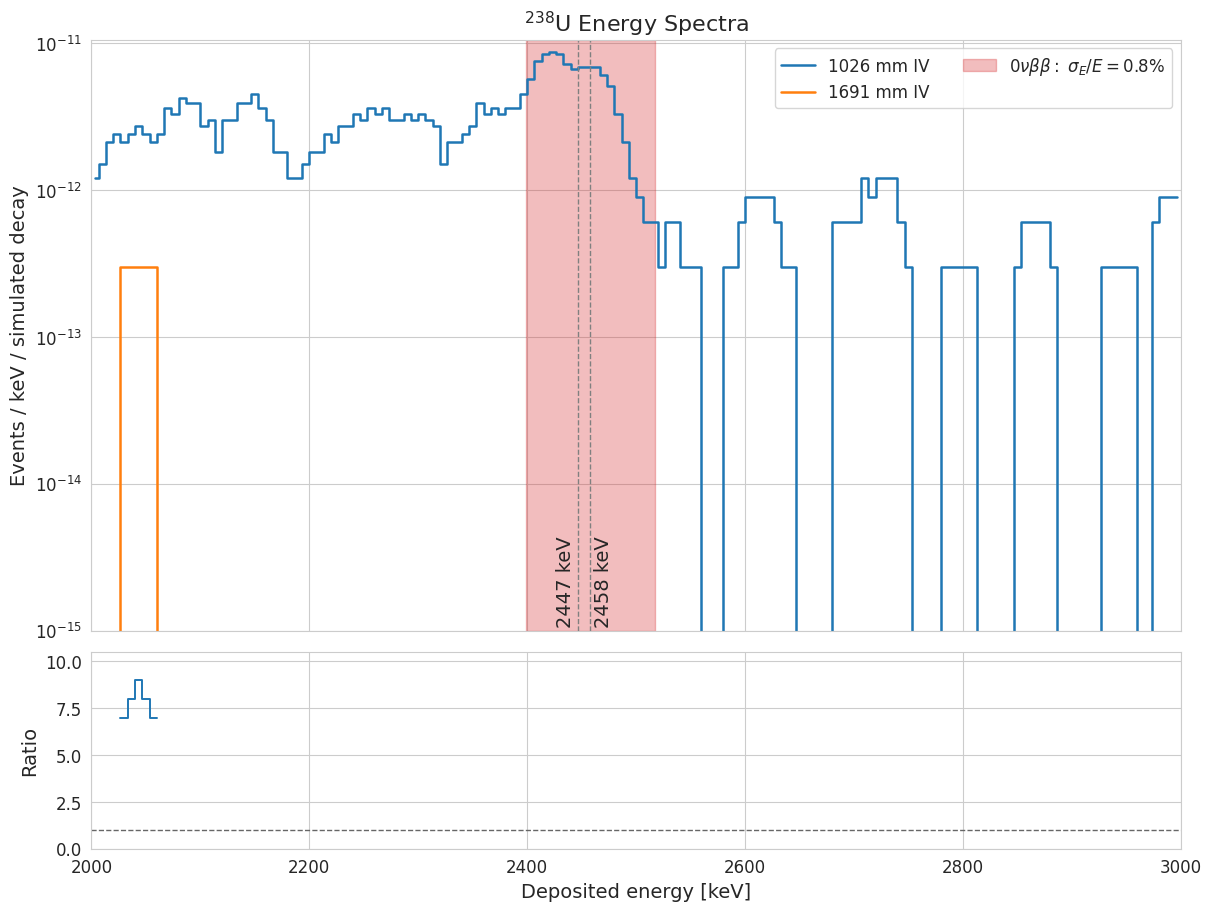

In [7]:
TRANSITION_BOX_CONFIG = {
    "reco_root": REPO_ROOT / "data/2025_09/TransitionBoxbkgd_amy0925-recon0925_DNN088",
    "input_root": Path("/p/lustre2/amy1/TransitionBoxbkgd_amy0925"),
    "radii": ["1026", "1691"],
    "reference_radius": "1691",
    "bins": 150,
    "emin": 2000.0,
    "emax": 3000.0,
    "smooth_bins": 5,
    "ratio_floor": 1e-20,
    "logy": True,
    "normalize_decays": True,
}

TRANSITION_BOX_ISOTOPES = {
    "Th232": {
        "ymin": 1e-15,
        "normalization_totals": 1e11,
    },
    "U238": {
        "ymin": 1e-15,
        "normalization_totals": 1e11,
    },
}

plot_component("Transition box", TRANSITION_BOX_CONFIG, TRANSITION_BOX_ISOTOPES)



## Baseline comparison (DNN / Energy / Standoff)

Loads IV radii from `data/2025_06/IVbkgd_amy0625_10B-recon0625_DNN088` and compares them to the baseline ROOT spectra.


In [8]:

def load_simulation_data(
    reco_root: Path,
    input_root: Path,
    radii: Iterable[str],
    isotopes: Iterable[str],
):
    all_isotope_data: Dict[str, pd.DataFrame] = {}

    for isotope in isotopes:
        frames: List[pd.DataFrame] = []
        for radius in radii:
            data_dir = reco_root / radius / isotope / "strax_data"
            input_base = input_root / radius / isotope / "data"

            run_ids = discover_runs(data_dir)
            if not run_ids:
                print(f"Skip {radius}/{isotope}: no runs found in {data_dir}")
                continue

            ctx = global_context(data_dir=str(data_dir), input_basepath=str(input_base))
            df = ctx.get_df(
                run_id=run_ids,
                run_id_as_bytes=True,
                targets=["Discriminator", "Energy", "Standoff"],
                progress_bar=False,
                multi_run_progress_bar=False,
            )

            # Normalize column names to lower-case for plotting
            df = df.rename(
                columns={
                    "Discriminator": "discriminator",
                    "Energy": "energy",
                    "Standoff": "standoff",
                }
            )
            df["radius"] = radius
            df["isotope"] = isotope
            frames.append(df)

        if frames:
            all_isotope_data[isotope] = pd.concat(frames, ignore_index=True)

    return all_isotope_data


def load_baseline(
    baseline_root: Path, isotopes: Iterable[str], dnn_cut: float, tree_name: str = "tree"
) -> Dict[str, Dict[str, pd.DataFrame]]:
    baseline: Dict[str, Dict[str, pd.DataFrame]] = {}
    for isotope in isotopes:
        file_path = baseline_root / f"Baseline2023_{isotope}_InnerCryostat.root"
        with uproot.open(file_path)[tree_name] as tree:
            df = tree.arrays(["m_DNNvalue", "energy", "standoff"], library="pd")

        df_cut = df[df["m_DNNvalue"] > dnn_cut]
        baseline[isotope] = {
            "raw": df,
            "dnn": df[["m_DNNvalue"]],
            "energy": df_cut[df_cut["energy"].between(0, 3500)],
            "standoff": df_cut,
        }

    return baseline


In [9]:
# IV distributions (all radii)

IV_RADII = ["1026mmIV", "1226mmIV", "1510mmIV", "1691mmIV"]
IV_ISOTOPES = ["Th232", "U238"]
IV_DNN_CUT = 0.88

IV_RECO_ROOT = REPO_ROOT / "data/2025_06/IVbkgd_amy0625_10B-recon0625_DNN088"
IV_INPUT_ROOT = Path("/p/lustre2/amy1/IVbkgd_amy0625_10B")
IV_BASELINE_ROOT = Path("/p/lustre2/nexouser/data/CD1-Sensitivity/merged-prod-20241202")

iv_isotope_data = load_simulation_data(IV_RECO_ROOT, IV_INPUT_ROOT, IV_RADII, IV_ISOTOPES)
iv_baseline_data = load_baseline(IV_BASELINE_ROOT, IV_ISOTOPES, IV_DNN_CUT)
summary = {iso: df.shape for iso, df in iv_isotope_data.items()}
baseline_summary = {iso: data["raw"].shape for iso, data in iv_baseline_data.items()}
print(f"Loaded IV data frames: {summary}")
print(f"Loaded baseline frames: {baseline_summary}")


Loaded IV data frames: {'Th232': (37464926, 30), 'U238': (2430686, 30)}
Loaded baseline frames: {'Th232': (357642, 3), 'U238': (63333, 3)}


In [10]:
column_map = {
    "dnn": ("discriminator", "m_DNNvalue"),
    "energy": ("energy", "energy"),
    "standoff": ("standoff", "standoff"),
}


def plot_kde(ax, df, var, label, **kwargs):
    if var in df.columns and not df.empty:
        values = df[var].replace([np.inf, -np.inf], np.nan).dropna()
        std = values.std()
        if len(values) > 1 and std > 1e-3:
            sns.kdeplot(data=values, ax=ax, label=label, **kwargs)
        elif len(values) > 1:
            ax.hist(values, bins=40, alpha=0.5, label=label)


def plot_distribution(
    var_key: str,
    label: str,
    title: str,
    *,
    sim_data: Dict[str, pd.DataFrame],
    isotopes: Iterable[str],
    radii: Iterable[str],
    dnn_cut: float,
    baseline: Optional[Dict[str, Dict[str, pd.DataFrame]]] = None,
    baseline_label: str = "Baseline",
    x_range=None,
    logy: bool = False,
    title_prefix: Optional[str] = None,
):
    sim_var, base_var = column_map[var_key]
    iso_list = list(isotopes)
    fig, axs = plt.subplots(1, len(iso_list), figsize=(7.5 * len(iso_list), 5))

    if len(iso_list) == 1:
        axs = [axs]

    for i, isotope in enumerate(iso_list):
        ax = axs[i]
        iso_label = format_isotope_label(isotope)
        df_all = sim_data.get(isotope)
        if df_all is None or df_all.empty:
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center")
            ax.set(xlabel=label, ylabel="Density", title=f"{iso_label} {title}")
            continue

        any_plotted = False
        for radius in radii:
            df_r = df_all[df_all["radius"] == radius].copy()
            if df_r.empty:
                continue

            df_plot = df_r
            display_label = format_radius_label(radius)
            if var_key == "energy":
                df_plot = df_plot[df_plot[sim_var].between(0, 3500)]

            plot_kde(ax, df_plot, sim_var, display_label, linestyle="--")
            any_plotted = True

            if var_key != "dnn":
                df_r_cut = df_plot[df_plot["discriminator"] > dnn_cut]
                if not df_r_cut.empty:
                    plot_kde(ax, df_r_cut, sim_var, f"{display_label} (DNN>{dnn_cut})", linestyle="--")

        base = baseline.get(isotope) if baseline else None
        if base is not None:
            if var_key == "dnn":
                plot_kde(ax, base["dnn"], base_var, baseline_label, linestyle="-")
            else:
                df_base_raw = base["raw"]
                df_base_raw = df_base_raw[df_base_raw[base_var].between(0, 3500)]
                df_base_cut = base[var_key]
                plot_kde(ax, df_base_raw, base_var, baseline_label, linestyle="-")
                plot_kde(ax, df_base_cut, base_var, f"{baseline_label} (DNN>cut)", linestyle="-")

        full_title = f"{iso_label} {title}"
        if title_prefix:
            full_title = f"{title_prefix}: {full_title}"

        ax.set(xlabel=label, ylabel="Density", title=full_title)
        if x_range:
            ax.set_xlim(x_range)
        if logy:
            ax.set_yscale("log")
            ax.set_ylim(1e-12, 1e-2)
        ax.grid(alpha=0.3)
        if any_plotted or base is not None:
            ax.legend()

    plt.tight_layout()
    plt.show()


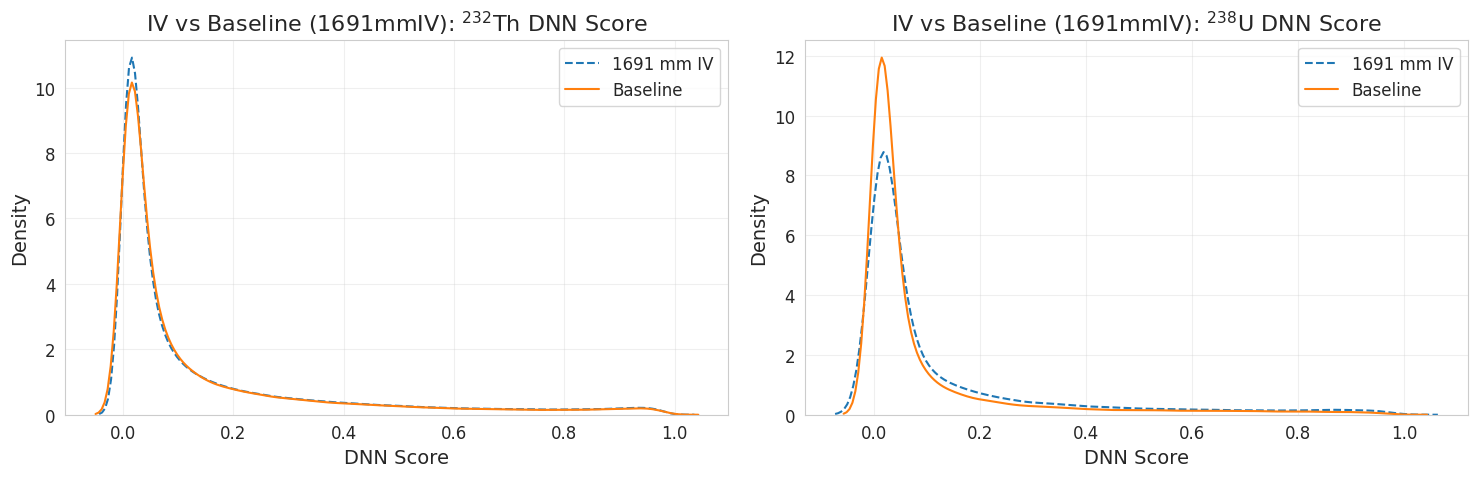

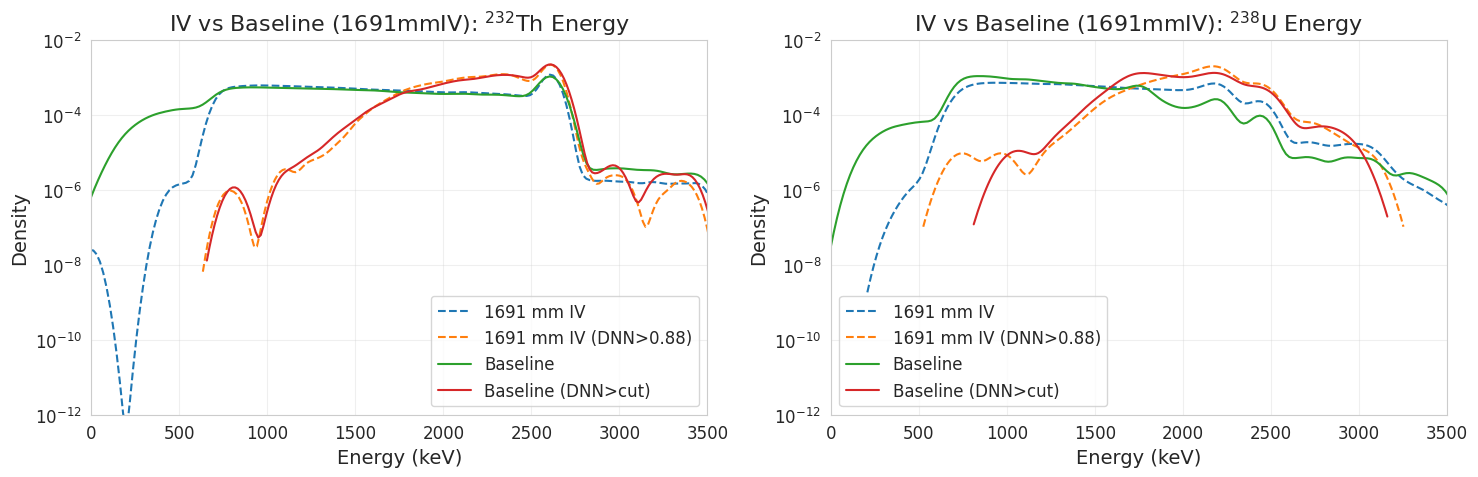

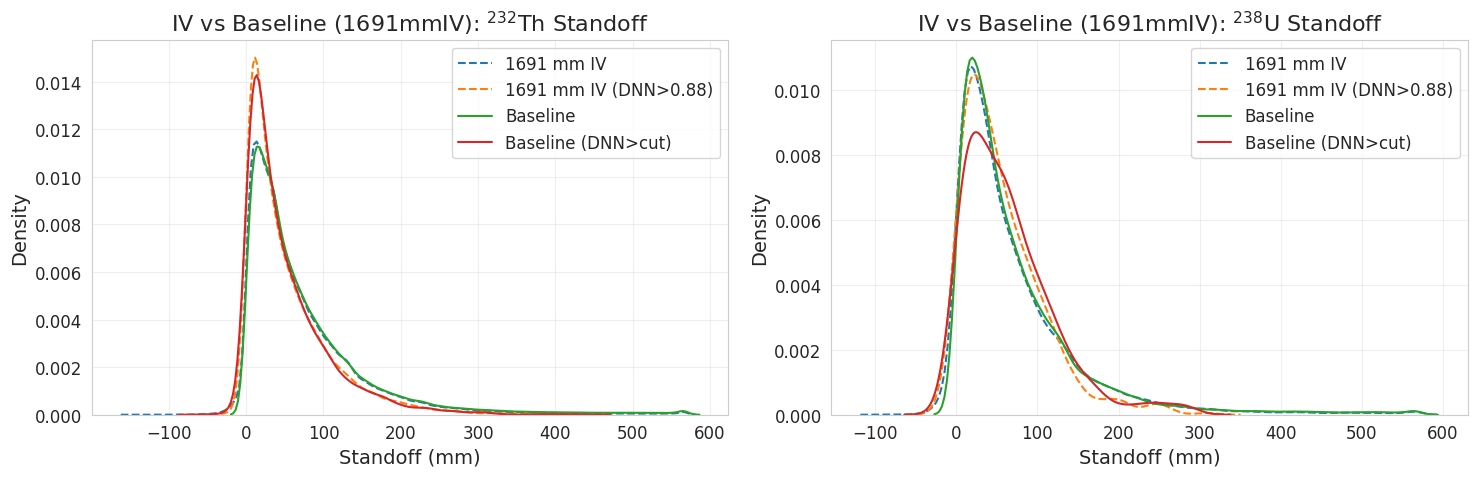

In [11]:
# Baseline overlay for IV

IV_BASELINE_RADIUS = "1691mmIV"

plot_distribution(
    "dnn",
    "DNN Score",
    "DNN Score",
    sim_data=iv_isotope_data,
    isotopes=IV_ISOTOPES,
    radii=[IV_BASELINE_RADIUS],
    dnn_cut=IV_DNN_CUT,
    baseline=iv_baseline_data,
    baseline_label="Baseline",
    title_prefix=f"IV vs Baseline ({IV_BASELINE_RADIUS})",
)
plot_distribution(
    "energy",
    "Energy (keV)",
    "Energy",
    sim_data=iv_isotope_data,
    isotopes=IV_ISOTOPES,
    radii=[IV_BASELINE_RADIUS],
    dnn_cut=IV_DNN_CUT,
    baseline=iv_baseline_data,
    baseline_label="Baseline",
    x_range=(0, 3500),
    logy=True,
    title_prefix=f"IV vs Baseline ({IV_BASELINE_RADIUS})",
)
plot_distribution(
    "standoff",
    "Standoff (mm)",
    "Standoff",
    sim_data=iv_isotope_data,
    isotopes=IV_ISOTOPES,
    radii=[IV_BASELINE_RADIUS],
    dnn_cut=IV_DNN_CUT,
    baseline=iv_baseline_data,
    baseline_label="Baseline",
    title_prefix=f"IV vs Baseline ({IV_BASELINE_RADIUS})",
)


## HFEbkgd distributions

Energy, DNN, and standoff shapes for the reconstructed HFE background production (all IV radii).


Loaded HFEbkgd data frames: {'Th232': (96958989, 30), 'U238': (1952146, 30)}


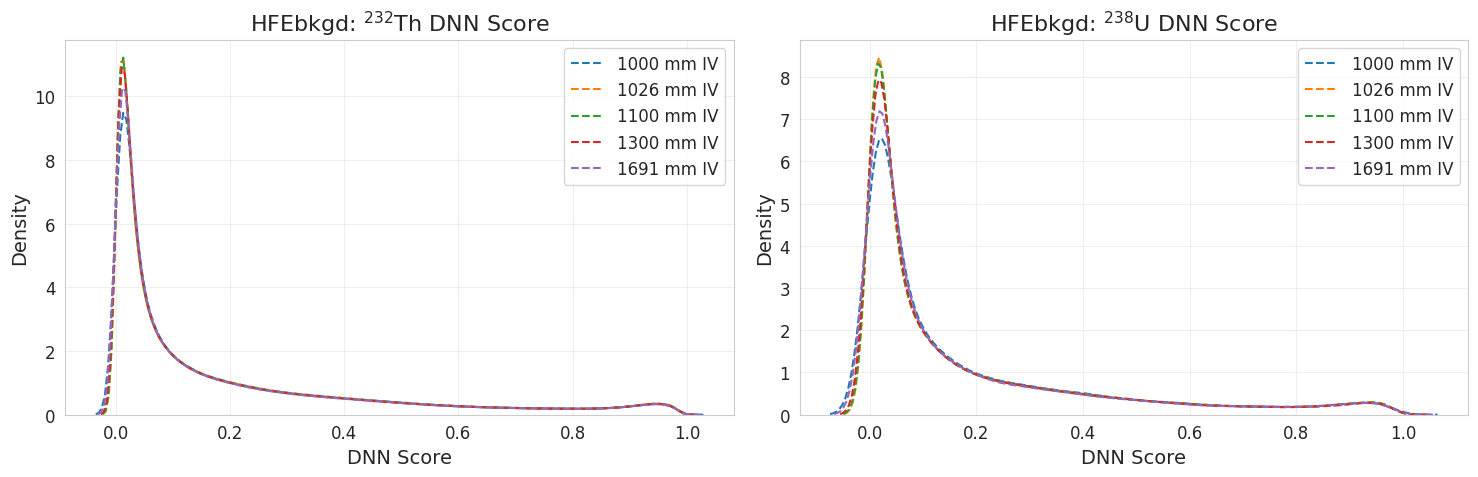

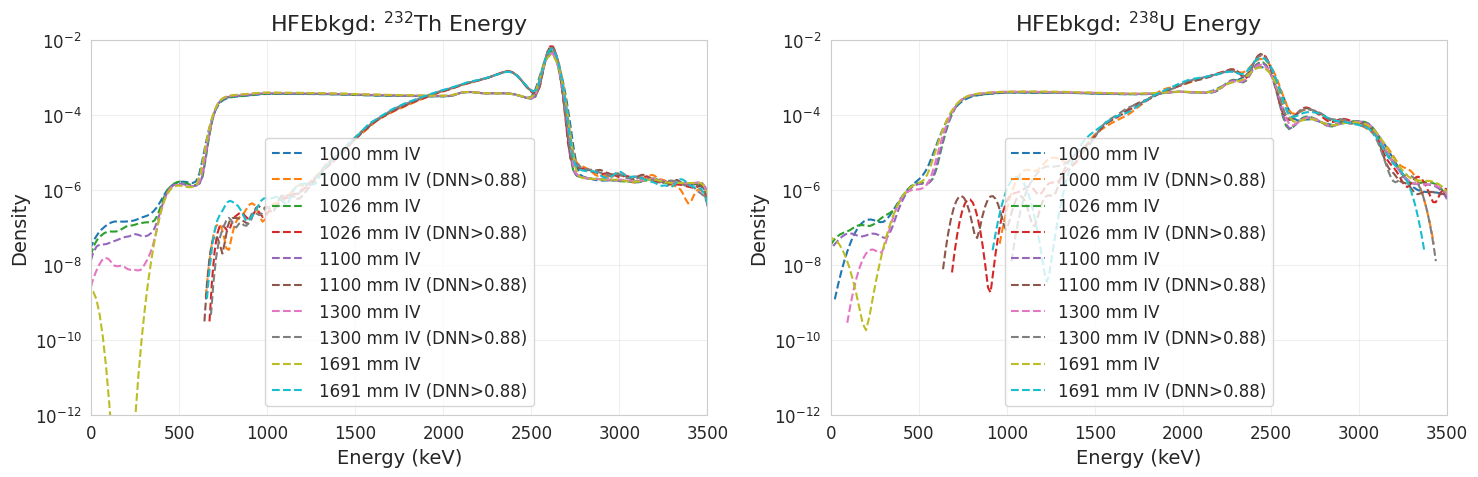

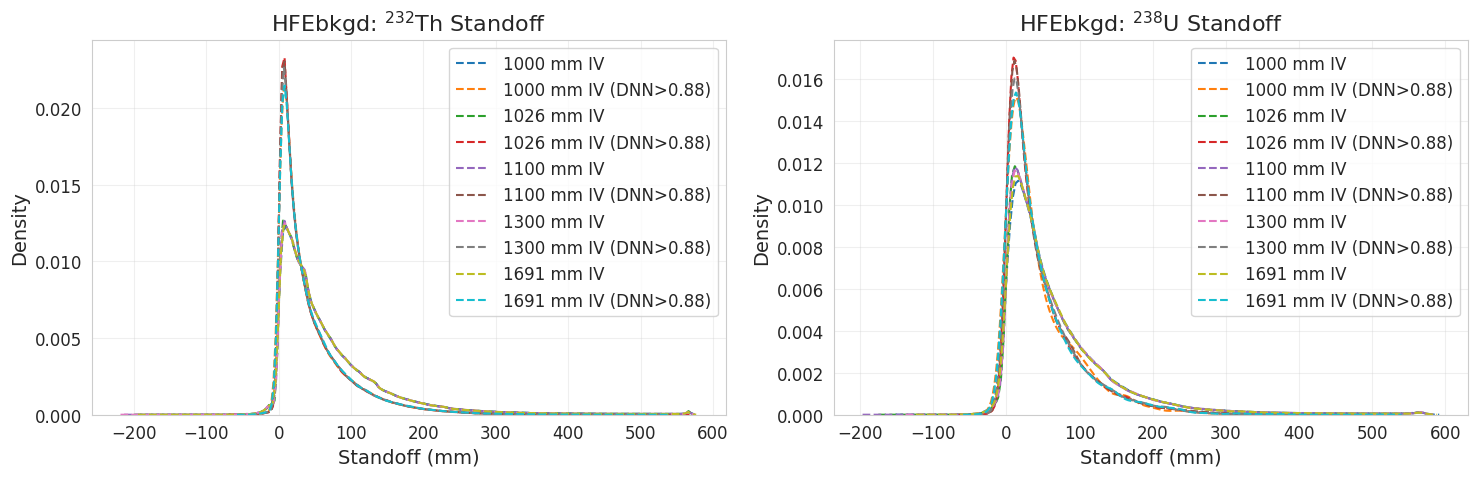

In [12]:
HFE_RADII = [
    "1000mmIV_HFE",
    "1026mmIV_HFE",
    "1100mmIV_HFE",
    "1300mmIV_HFE",
    "1691mmIV_HFE",
]
HFE_ISOTOPES = ["Th232", "U238"]
HFE_DNN_CUT = 0.88

HFE_RECO_ROOT = REPO_ROOT / "data/2025_06/HFEbkgd_amy0625_1B-recon0625_DNN088"
HFE_INPUT_ROOT = Path("/p/lustre1/amy1/HFEbkgd_amy0625_1B")

hfe_isotope_data = load_simulation_data(HFE_RECO_ROOT, HFE_INPUT_ROOT, HFE_RADII, HFE_ISOTOPES)
hfe_summary = {iso: df.shape for iso, df in hfe_isotope_data.items()}
print(f"Loaded HFEbkgd data frames: {hfe_summary}")

plot_distribution(
    "dnn",
    "DNN Score",
    "DNN Score",
    sim_data=hfe_isotope_data,
    isotopes=HFE_ISOTOPES,
    radii=HFE_RADII,
    dnn_cut=HFE_DNN_CUT,
    baseline=None,
    title_prefix="HFEbkgd",
)
plot_distribution(
    "energy",
    "Energy (keV)",
    "Energy",
    sim_data=hfe_isotope_data,
    isotopes=HFE_ISOTOPES,
    radii=HFE_RADII,
    dnn_cut=HFE_DNN_CUT,
    baseline=None,
    x_range=(0, 3500),
    logy=True,
    title_prefix="HFEbkgd",
)
plot_distribution(
    "standoff",
    "Standoff (mm)",
    "Standoff",
    sim_data=hfe_isotope_data,
    isotopes=HFE_ISOTOPES,
    radii=HFE_RADII,
    dnn_cut=HFE_DNN_CUT,
    baseline=None,
    title_prefix="HFEbkgd",
)
